In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.preprocessing import  LabelEncoder,StandardScaler,OneHotEncoder
from sklearn.metrics import confusion_matrix,accuracy_score

In [2]:
df=pd.read_csv("project_shopping_trends.csv")
df.sample(5)

,Customer_ID,Age,Gender,Item_Purchased,Category,Purchase_Amount_USD,Location,Size,Color,Season,Review_Rating,Subscription_Status,Payment_Method,Shipping_Type,Discount_Applied,Promo_Code_Used,Previous_Purchases,Preferred_Payment_Method,Frequency_of_Purchases,cluster
521,522,36,Male,Shorts,Clothing,3,Vermont,L,Gold,Winter,3,Yes,Credit Card,Standard,Yes,Yes,50,Bank Transfer,Annually,0
1792,1793,38,Male,Sneakers,Footwear,3,Iowa,M,Peach,Fall,3,No,Bank Transfer,Express,No,No,22,Debit Card,Every 3 Months,0
2356,2357,57,Male,Backpack,Accessories,3,Montana,M,Gray,Summer,3,No,Bank Transfer,Free Shipping,No,No,27,Debit Card,Quarterly,2
1260,1261,63,Male,Shirt,Clothing,4,Virginia,XL,Green,Spring,4,No,Venmo,Store Pickup,Yes,Yes,30,Debit Card,Quarterly,2
7046,3147,29,Male,Phone,Electronics,5,New York,XL,Green,Fall,5,Yes,Standard,Yes,Yes,7,25,Weekly,20s,0


In [3]:
print(df.describe)
print(df.info())

<bound method NDFrame.describe of       Customer_ID  Age  Gender Item_Purchased    Category  \
0               1   55    Male         Blouse    Clothing   
1               2   19    Male        Sweater    Clothing   
2               3   50    Male          Jeans    Clothing   
3               4   21    Male        Sandals    Footwear   
4               5   45    Male         Blouse    Clothing   
...           ...  ...     ...            ...         ...   
7795         3896   39  Female       Football  Home Decor   
7796         3897   50    Male        T-Shirt      Sports   
7797         3898   53  Female          Shoes      Sports   
7798         3899   62  Female          Watch    Clothing   
7799         3900   40    Male       Curtains    Clothing   

      Purchase_Amount_USD       Location Size      Color  Season  \
0                       3       Kentucky    L       Gray  Winter   
1                       3          Maine    L     Maroon  Winter   
2                       3  Ma

In [4]:
df.columns

Index(['Customer_ID', 'Age', 'Gender', 'Item_Purchased', 'Category',
       'Purchase_Amount_USD', 'Location', 'Size', 'Color', 'Season',
       'Review_Rating', 'Subscription_Status', 'Payment_Method',
       'Shipping_Type', 'Discount_Applied', 'Promo_Code_Used',
       'Previous_Purchases', 'Preferred_Payment_Method',
       'Frequency_of_Purchases', 'cluster'],
      dtype='str')

In [5]:
print(df.shape)
print(df.dtypes)

(7800, 20)
Customer_ID                 int64
Age                         int64
Gender                        str
Item_Purchased                str
Category                      str
Purchase_Amount_USD         int64
Location                      str
Size                          str
Color                         str
Season                        str
Review_Rating               int64
Subscription_Status           str
Payment_Method                str
Shipping_Type                 str
Discount_Applied              str
Promo_Code_Used               str
Previous_Purchases          int64
Preferred_Payment_Method      str
Frequency_of_Purchases        str
cluster                     int64
dtype: object


In [6]:
df["Age"].unique()

array([55, 19, 50, 21, 45, 46, 63, 27, 26, 57, 53, 30, 61, 65, 64, 25, 52,
       66, 31, 56, 18, 38, 54, 33, 36, 35, 29, 70, 69, 67, 20, 39, 42, 68,
       49, 59, 47, 40, 41, 48, 22, 24, 44, 37, 58, 32, 62, 51, 28, 43, 34,
       23, 60])

In [7]:
## convert numeric
df["Age"]=pd.to_numeric(df["Age"],errors="coerce")
df["Age"]=df["Age"].fillna(df["Age"].mean())
df["Age"]=df["Age"].astype(int)

In [8]:
df["Previous_Purchases"].unique()
df["Previous_Purchases"]=pd.to_numeric(df["Previous_Purchases"],errors="coerce")
df["Previous_Purchases"]=df["Previous_Purchases"].fillna(df["Previous_Purchases"].mean())
df["Previous_Purchases"]=df["Previous_Purchases"].astype(int)


In [9]:
df["Review_Rating"].unique()
df["Review_Rating"]=pd.to_numeric(df["Review_Rating"],errors="coerce")
df["Review_Rating"]=df["Review_Rating"].fillna(df["Review_Rating"].mean())
df["Review_Rating"]=df["Review_Rating"].astype(int)

In [10]:
df["Purchase_Amount_USD"].unique()
df["Purchase_Amount_USD"]=pd.to_numeric(df["Review_Rating"],errors="coerce")
df["Purchase_Amount_USD"]=df["Purchase_Amount_USD"].fillna(df["Purchase_Amount_USD"].mean())
df["Purchase_Amount_USD"]=df["Purchase_Amount_USD"].astype(int)

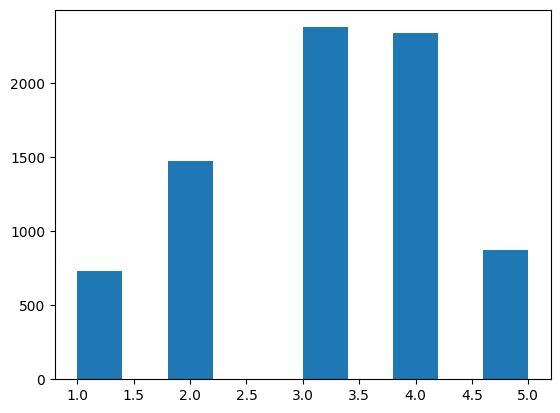

In [11]:
plt.hist(df["Purchase_Amount_USD"])
plt.show()

In [12]:
df_sub=df[["Age","Previous_Purchases","Review_Rating","Purchase_Amount_USD"]]
df_sub.sample(4)

,Age,Previous_Purchases,Review_Rating,Purchase_Amount_USD
4298,49,25,4,4
4176,37,25,1,1
5005,22,25,1,1
679,56,37,3,3


In [13]:
df_sub.dtypes

Age                    int64
Previous_Purchases     int64
Review_Rating          int64
Purchase_Amount_USD    int64
dtype: object

In [14]:
print(df_sub['Age'].head())
print(df_sub['Age'].dtype)

0    55
1    19
2    50
3    21
4    45
Name: Age, dtype: int64
int64


In [15]:
print(df_sub['Age'].dtype)

int64


In [16]:
df_sub.sample(5)

,Age,Previous_Purchases,Review_Rating,Purchase_Amount_USD
4639,45,25,5,5
5826,49,25,3,3
1685,33,43,4,4
3249,26,32,3,3
7733,36,25,2,2


In [17]:
df.corr

<bound method DataFrame.corr of       Customer_ID  Age  Gender Item_Purchased    Category  \
0               1   55    Male         Blouse    Clothing   
1               2   19    Male        Sweater    Clothing   
2               3   50    Male          Jeans    Clothing   
3               4   21    Male        Sandals    Footwear   
4               5   45    Male         Blouse    Clothing   
...           ...  ...     ...            ...         ...   
7795         3896   39  Female       Football  Home Decor   
7796         3897   50    Male        T-Shirt      Sports   
7797         3898   53  Female          Shoes      Sports   
7798         3899   62  Female          Watch    Clothing   
7799         3900   40    Male       Curtains    Clothing   

      Purchase_Amount_USD       Location Size      Color  Season  \
0                       3       Kentucky    L       Gray  Winter   
1                       3          Maine    L     Maroon  Winter   
2                       3  Mass

In [18]:
x=df_sub
print(x)

      Age  Previous_Purchases  Review_Rating  Purchase_Amount_USD
0      55                  14              3                    3
1      19                   2              3                    3
2      50                  23              3                    3
3      21                  49              3                    3
4      45                  31              2                    2
...   ...                 ...            ...                  ...
7795   39                  25              4                    4
7796   50                  25              4                    4
7797   53                  25              2                    2
7798   62                  25              1                    1
7799   40                  25              2                    2

[7800 rows x 4 columns]


In [19]:
print(x.dtypes)

Age                    int64
Previous_Purchases     int64
Review_Rating          int64
Purchase_Amount_USD    int64
dtype: object


In [20]:
sc=StandardScaler()
x_sc=sc.fit_transform(x)
print(x_sc)

[[ 0.85597848 -1.09396237 -0.13045704 -0.13045704]
 [-1.63587037 -2.2686062  -0.13045704 -0.13045704]
 [ 0.50988836 -0.21297949 -0.13045704 -0.13045704]
 ...
 [ 0.71754243 -0.01720552 -1.01070348 -1.01070348]
 [ 1.34050464 -0.01720552 -1.89094993 -1.89094993]
 [-0.18229188 -0.01720552 -1.01070348 -1.01070348]]


In [21]:
wcss=[]
for i in range(1,11):
    km=KMeans(n_clusters=i,random_state=42)
    km.fit(x_sc)
    wcss.append(km.inertia_)

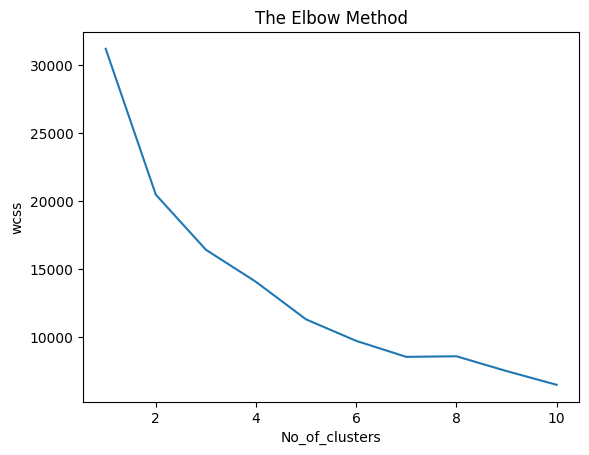

In [22]:
plt.plot(range(1,11),wcss)
plt.title("The Elbow Method")
plt.xlabel("No_of_clusters")
plt.ylabel("wcss")
plt.show()

In [23]:
km=KMeans(n_clusters=3,random_state=42)
cluster=km.fit_predict(x_sc)
df["cluster"]=cluster


In [24]:
df.sample(5)

,Customer_ID,Age,Gender,Item_Purchased,Category,Purchase_Amount_USD,Location,Size,Color,Season,Review_Rating,Subscription_Status,Payment_Method,Shipping_Type,Discount_Applied,Promo_Code_Used,Previous_Purchases,Preferred_Payment_Method,Frequency_of_Purchases,cluster
1020,1021,24,Male,Scarf,Accessories,4,Delaware,M,Black,Fall,4,Yes,Bank Transfer,Express,Yes,Yes,41,Debit Card,Annually,0
2239,2240,42,Male,Jewelry,Accessories,3,Alabama,L,Indigo,Summer,3,No,Bank Transfer,2-Day Shipping,No,No,41,Credit Card,Every 3 Months,2
6748,2849,62,Female,T-Shirt,Home Decor,3,Miami,M,Blue,Spring,3,No,Express,Yes,Yes,3,25,Monthly,60+,2
6424,2525,26,Female,Football,Accessories,5,Chicago,L,Black,Summer,5,Yes,Standard,Yes,Yes,13,25,Fortnightly,20s,0
4688,789,55,Male,Phone,Clothing,3,New York,L,Black,Spring,3,Yes,Standard,Yes,Yes,11,25,Weekly,50s,2


In [25]:
df.groupby("cluster")[
    [ "Age",
     "Purchase_Amount_USD",
     "Previous_Purchases",
     "Review_Rating"]
].mean()

,Age,Purchase_Amount_USD,Previous_Purchases,Review_Rating
cluster,,,,
0,30.415789,3.764912,23.835439,3.764912
1,42.410617,1.668330,25.008621,1.668330
2,55.493081,3.695921,26.701020,3.695921


In [26]:
df.to_csv("project_shopping_trends.csv", index=False)